In [1]:
import os
import pickle as pkl

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

SAVE = False  # whether to save the outputs of this notebook

if SAVE:
    # Replace this with the path to directory where you would like results to be saved
    OUTPUT_PATH = "./data"
    os.makedirs(OUTPUT_PATH, exist_ok=True)  # Create path if it doesn't exist

In [2]:
import pandas as pd
import numpy as np

In [3]:
DGE_res = pd.read_pickle('./data/ds.pkl')

Running Wald tests...
... done in 64.66 seconds.



Log2 fold change & Wald test p-value: condition F vs M
          baseMean  log2FoldChange     lfcSE      stat        pvalue  \
PPARA   315.451816       -0.049456  0.025886  0.000000  1.000000e+00   
FRMD6    27.841337        0.382634  0.049011  5.766774  8.080322e-09   
CAP2     15.109846        0.142116  0.040974  1.027861  3.040152e-01   
ACADM   457.037799        0.100114  0.035934  0.003184  9.974595e-01   
ING1     36.618146       -0.020696  0.033033  0.000000  1.000000e+00   
...            ...             ...       ...       ...           ...   
NYNRIN   10.430389        0.099629  0.051277  0.000000  1.000000e+00   
UBR5    101.414445       -0.079880  0.023372  0.000000  1.000000e+00   
BDH2    140.404644       -0.094914  0.057906  0.000000  1.000000e+00   
TRIO     58.714219       -0.054960  0.030182  0.000000  1.000000e+00   
NOVA2     4.036923       -0.017475  0.059267  0.000000  1.000000e+00   

                padj  
PPARA   1.000000e+00  
FRMD6   5.135062e-07  
CAP2    1.0

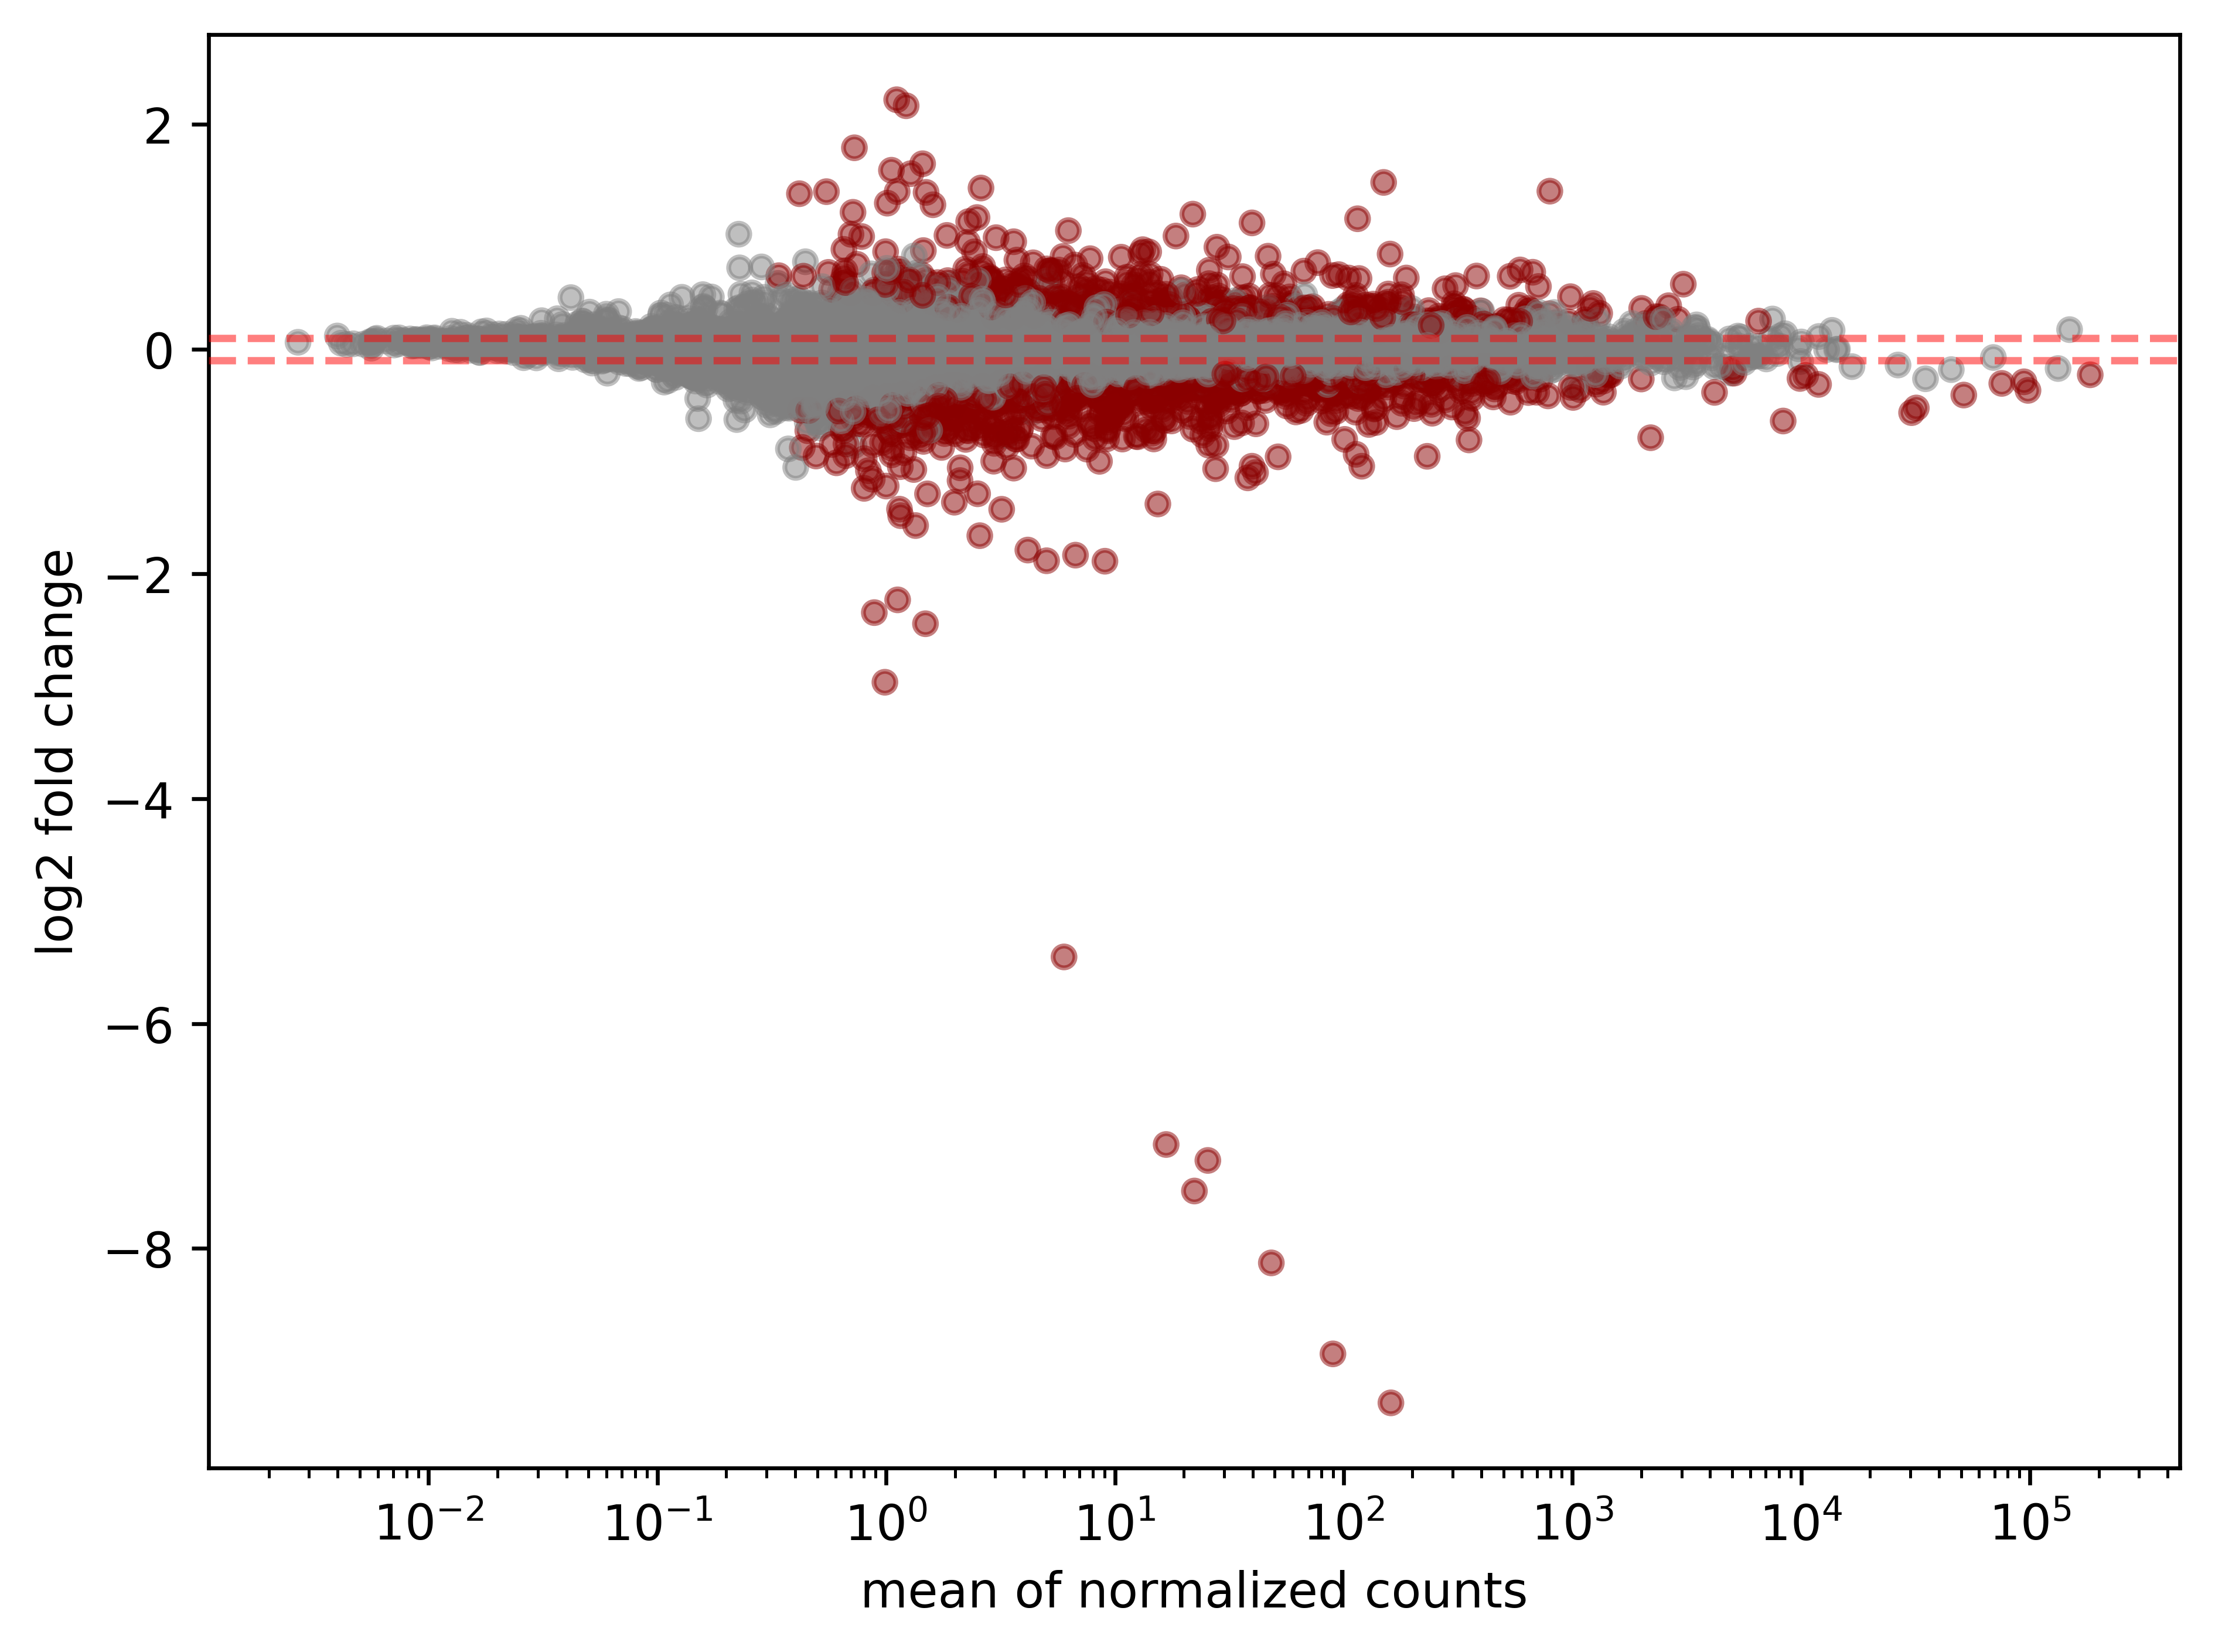

In [4]:
#look for log fold changes sig greater than 1
LFC1_res = DGE_res.summary(lfc_null=0.1, alt_hypothesis="greaterAbs")
DGE_res.plot_MA(s=20)

In [5]:
de = DGE_res.results_df
de['logP'] = (np.log10(de['padj'])) * -1

/home/alexanderb/miniconda3/envs/DGE_env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,logP
PPARA,315.451816,-0.049456,0.025886,0.000000,1.000000e+00,1.000000e+00,-0.000000
FRMD6,27.841337,0.382634,0.049011,5.766774,8.080322e-09,5.135062e-07,6.289454
CAP2,15.109846,0.142116,0.040974,1.027861,3.040152e-01,1.000000e+00,-0.000000
ACADM,457.037799,0.100114,0.035934,0.003184,9.974595e-01,1.000000e+00,-0.000000
ING1,36.618146,-0.020696,0.033033,0.000000,1.000000e+00,1.000000e+00,-0.000000
...,...,...,...,...,...,...,...
NYNRIN,10.430389,0.099629,0.051277,0.000000,1.000000e+00,1.000000e+00,-0.000000
UBR5,101.414445,-0.079880,0.023372,0.000000,1.000000e+00,1.000000e+00,-0.000000
BDH2,140.404644,-0.094914,0.057906,0.000000,1.000000e+00,1.000000e+00,-0.000000
TRIO,58.714219,-0.054960,0.030182,0.000000,1.000000e+00,1.000000e+00,-0.000000


In [7]:
for gene in de[de['log2FoldChange'] > 0.1].index:
    print(gene)

FRMD6
CAP2
ACADM
TMEM204
EDF1
NDC80
VPS51
HSD11B1
FMO3
KDELR3
SLC25A1
NUDCD3
BTBD2
ZNF669
FOXN4
GPR153
UGT2B15
FAM50B
FREM2
DBN1
GPS1
LMX1B
LRP5
CYP2C19
TBC1D14
AQP5
ASTN1
MYG1
NUDT18
ZNF598
ORC1
RHOF
HR
COMTD1
DSCAML1
SERPINE1
SFRP1
MGAT3
PAQR4
SYT9
DPP4
FEN1
PCLAF
SPATA18
CCL4L2
CRACR2B
ZNF253
MRPS2
UBE2T
ACE2
CSE1L
MAD1L1
CACNG5
NOSIP
TAF1B
APC2
CYP2C9
TTLL1
ARHGAP45
UQCC3
FOLR3
PPP4C
FSTL3
TAS1R3
CDC37
JOSD2
SHF
TMIE
SLC51B
ZNF502
ENO1
CCL7
APEH
TNS1
NPM2
SEMA3D
ZFP92
FXYD2
DRAP1
PPIL2
ZNF653
RRM2
RGMA
LTC4S
GALNT15
TBXA2R
TRIB3
CDK16
NUPR1
CNN2
WDR18
ORAI3
ELFN1
PTPRU
CNTNAP2
NHLRC4
FUT1
CCDC3
CYP1A1
ARHGEF1
DTX1
BAAT
CDKN3
PCDHB13
APRT
PNP
ADM5
MRTFA
BTBD9
FOXP3
KLC3
ORMDL3
FAM229B
LAMP3
PFN2
CYP3A4
NOL4
KIF12
MIA
CCL8
COL11A2
AGR3
RETN
RASSF10
ZBTB20
SQOR
RNF169
ITGB3BP
KIF1A
CIAO3
MMP3
AKR1C4
PIAS4
KIF13B
PEDS1-UBE2V1
PTPRT
PLD1
FIGNL1
ANTXR1
ATP9B
DUSP6
RHOC
FIBIN
SREBF1
WDR48
TNFRSF11A
LECT2
TMEM144
NHP2
ITIH1
KITLG
HIP1R
PRPF8
MMP9
AKR1C3
CHEK1
FOLR1
WNT5A
ADCY8
CILP2
MAB21L

In [8]:
for gene in de.index:
    print(gene)

PPARA
FRMD6
CAP2
ACADM
ING1
TMEM204
RASGRF2
SLC34A1
ZNF174
IFNLR1
ANKRD16
ZNF844
NSG1
EDF1
EMX1
ABCC1
DGKH
NDC80
ZNF19
KANSL2
VPS51
HSD11B1
NOP58
FMO3
KDELR3
CCNB1IP1
DHX8
SLC25A1
SHROOM1
ZDHHC3
EIF2B4
ZFP57
NUDCD3
BTBD2
SMCO4
PRDM8
LIPN
PLEKHM1
NALCN
RAD51B
ZNF669
FOXN4
MFSD10
SLFN12
GPR153
DOCK10
RIT1
EZH2
XPNPEP1
DHX29
ANXA9
SORT1
STRN
CEP43
H3-7
KIAA2013
RASD1
UBAC2
SERTAD2
KAT14
TMEM104
MSLN
PRPF38A
UGT2B15
FERMT2
AFTPH
CUEDC2
CLOCK
TMEM8B
FAM50B
ALCAM
GNB5
STAU2
PARP12
FREM2
FRK
GSTA4
ACVRL1
RAB3GAP2
NAT16
NSD3
HOXB6
INPPL1
SLC6A7
DBN1
CCDC110
BBOF1
NUP133
COMMD7
PGAP2
GPS1
STARD13
TMPRSS11D
LRRC63
MRTO4
APOF
GRB14
SRA1
ISY1-RAB43
EDEM2
LMX1B
CASP9
SYNJ1
H1-0
FBXO48
TLR8
ST8SIA1
TMEM177
LRP5
ITGA10
RFLNA
PROKR2
RFNG
SLX1B
PEX6
CYP2C19
ZDHHC6
PPP4R3B
HTT
PCSK1N
GTF2IRD2B
BACE2
RIMS4
WDR1
CHRM5
TBC1D14
ZNF66
SLC43A1
KDM7A
SNX14
STK4
AQP5
CD274
ZSCAN12
DNAJB2
ADAM17
NDUFAB1
PSEN1
MACC1
STX2
RAD51C
RAB6C
ARL8B
ZNF789
TP53RK
CD80
SARS2
IGF1R
LCA5L
ZNF574
OSBPL11
VANGL1
ARHGEF33
PTPRR


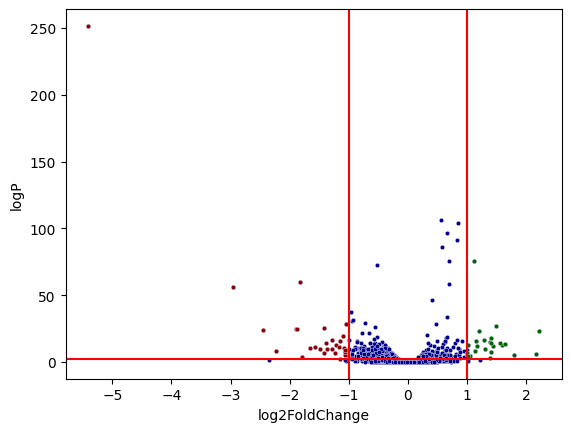

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(ncols = 1)
sns.set_style('white')

sns.scatterplot(data = de, x = 'log2FoldChange', y = 'logP', ax=ax, s = 10, color = 'darkblue')
sns.despine
plt.axvline(-1, color = 'red')
plt.axvline(1, color = 'red')
plt.axhline(np.log10(0.01) * -1, color = 'red')

sns.scatterplot(data = de[((de['log2FoldChange'] < - 1)) & ((de['padj'] < 0.01))], x = 'log2FoldChange', y = 'logP', ax=ax, s = 10, color = 'darkred')
sns.scatterplot(data = de[((de['log2FoldChange'] > 1)) & ((de['padj'] < 0.01))], x = 'log2FoldChange', y = 'logP', ax=ax, s = 10, color = 'darkgreen')

plt.savefig('./figures/Male_Female_volcano', bbox_inches = 'tight', dpi = 300)

In [10]:
sig_DEG = de[de['padj'] < 0.05]
sig_2LFC = sig_DEG[abs(sig_DEG['log2FoldChange']) > 2 ]

In [11]:
with open(f'./data/DGEs.txt', 'w+') as f:
    for gene in sig_DEG.index:
        f.write(f'{gene}\n')
f.close

<function TextIOWrapper.close()>

# Comparing DGEs and differntially regulated genes

In [12]:
f = open('/home/alexanderb/Zhang_lab/MML_model/GRN_reconstruction/data/0.1_differential_all_highAcc.txt')
diff_regged = set(f.read().split('\n'))
f.close()

In [13]:
DGEs = set(sig_DEG.index)

In [21]:
for gene in DGEs:
    print(gene)

N4BP2L2
ATP6V0E1
PLP2
SCRN2
DHFR2
ATP6V1C2
CYP2B6
ALG10
TTC6
FKBP11
PRAF2
ATP2B4
ITGA10
ZFP36L2
H2BC11
SOCS3
IGFLR1
JAK3
IFIT3
SYNE2
ZMAT1
ZNF440
POLG2
ALDH1B1
ZNF585B
RHOQ
CENATAC
TKFC
CAMK1D
DYRK3
SLC5A6
KCNAB3
NABP1
ZNF274
ADRA2C
FGF23
IQCN
MGLL
KLHL3
LRAT
MOK
SLC43A3
SOX4
HARS1
SLAMF7
TDGF1
ZNF75A
KCNJ8
ZNF600
NRG1
MBP
HOOK2
PLEK2
MMP10
NAIP
ATP1B3
TMEM187
BIRC3
NLRP1
ORC6
AKR1C2
CCNL1
RNF175
TSKU
LMNB1
BCO1
CYP3A4
SPATA6L
SLC38A3
TARS3
AKR1C1
KCNK5
FCRL5
MEI4
IP6K3
DNAH6
UBE2QL1
GTPBP1
CREBZF
TTLL3
SLC25A15
ARHGAP44
PRSS35
KCNMB3
SULF2
SUGP2
SCGB3A2
BAG3
CCL5
BMERB1
PNISR
MARVELD3
TTC13
AFF3
UBXN8
CD33
SOX7
ZNF682
ZBED3
IL3RA
BTAF1
AVPR1A
NID1
CHAD
SRXN1
MYH3
CENPU
NUDT13
SLC1A3
PFN2
PHF11
CYP3A7
TRIM22
RFC3
KLRG1
SPDYA
DUSP8
HAAO
DNAH11
MCM5
EBF1
COL6A1
RNPC3
WNT9B
SREK1
MT1M
ILDR2
LIPE
PRG2
ARMC12
SGCB
SLAMF1
MTUS1
APOA4
ESPNL
CTH
RBP7
CD47
RHOBTB2
SLC39A10
GABRE
NRBP2
GATM
LRRC7
PTH2R
NALCN
PIGL
CCNT2
B3GAT2
FGG
ZC3H11A
MSH2
CTSG
GLA
JAM2
SP140
MPO
ZNF554
ABCA3
MRNIP
SAA2
BACE2

In [15]:
len(diff_regged & DGEs)

134

In [16]:
len(DGEs)

1376

In [17]:
len(diff_regged)

1602

In [18]:
for gene in (diff_regged - DGEs):
    print(gene)


NFYA
ENOPH1
PRRX2
RAE1
ZDHHC6
SIK1
NANOG
IRF8
ZNF79
TFE3
POU5F1B
OSR1
SLC25A4
ADNP
RAB21
SNAI1
DTNB
BEX3
LEF1
ZNF287
ZNF264
ATF6
ZNF502
ALX4
CAMTA1
HSD17B8
RNF167
ARX
ZNF713
PPIL2
EPAS1
IRF3
IRF7
ZNF91
HEY2
ZBTB38
ZNF799
WDR7
ZNF410
KLF1
BAX
NR1H3
TBX6
IFRD2
CTTNBP2NL
CTDP1
SRF
RGS5
HES1
SPRED2
ARGFX
CREB5
ZKSCAN5
SOX18
MEF2B
UBE2G1
PSMD14
ZNF860
HOXA7
ZNF7
PLSCR1
MZF1
CC2D1A
YWHAB
PRDM8
TBP
NFATC3
ZSCAN1
SMAD1
NONO
FOXM1
CRY1
FOXF2
CASP8
ZNF184
FOXO6
ZNF778
ZNF296
ATOH8
DR1
OVOL2
EGR3
XPA
TSHZ3
FOXN2
ZSCAN9
GTF2B
KAT6B
ARNT
NFATC1
VAT1
MYB
IRF9
ZNF250
ZHX1
ZNF81
TBR1
NKX6-2
CEBPD
ZNF160
YTHDC2
SPDEF
TBX15
PSMD4
GATA2
CCDC125
FOXO1
EOLA2
DDIT3
LGR4
SMAD4
AKNA
KHDRBS3
TCFL5
HMBOX1
CREB3L4
HIVEP3
HOXB2
CHMP4A
PRDX3
GDF7
ZNF37A
EBF3
EHF
GUCY1B1
ETV1
ZNF701
ZNF791
SCP2
ZNF143
TSC22D1
HMGA2
PARD6G
KLF10
CCT5
POLR2H
INTU
ZNF416
ST3GAL1
HESX1
RORA
ZFAT
HMGA1
ZNF708
ZNF704
PRDM16
NEK3
DPY30
RPL36
SMAD3
ZNF213
NFIA
FUNDC2
CLDND1
ETS1
ITGB1BP1
TCF12
NMNAT1
TP63
IKZF1
RPAP3
SALL3
SOX6
ZNF582
ARN

In [19]:
for gene in (DGEs - diff_regged):
    print(gene)

N4BP2L2
SCRN2
DHFR2
ATP6V1C2
CYP2B6
ALG10
TTC6
FKBP11
PRAF2
ITGA10
ZFP36L2
H2BC11
SOCS3
IGFLR1
JAK3
SYNE2
ZMAT1
POLG2
ALDH1B1
RHOQ
CENATAC
TKFC
CAMK1D
DYRK3
SLC5A6
KCNAB3
NABP1
ADRA2C
FGF23
IQCN
MGLL
KLHL3
LRAT
SLC43A3
HARS1
SLAMF7
TDGF1
KCNJ8
ZNF600
NRG1
MBP
HOOK2
PLEK2
MMP10
NAIP
ATP1B3
TMEM187
ORC6
BIRC3
NLRP1
AKR1C2
CCNL1
RNF175
TSKU
LMNB1
BCO1
CYP3A4
SPATA6L
SLC38A3
TARS3
AKR1C1
KCNK5
FCRL5
MEI4
IP6K3
DNAH6
UBE2QL1
GTPBP1
TTLL3
SLC25A15
ARHGAP44
PRSS35
KCNMB3
SULF2
SCGB3A2
BAG3
CCL5
BMERB1
PNISR
MARVELD3
TTC13
AFF3
UBXN8
CD33
ZBED3
IL3RA
BTAF1
AVPR1A
NID1
CHAD
SRXN1
MYH3
CENPU
NUDT13
SLC1A3
PFN2
PHF11
CYP3A7
RFC3
KLRG1
SPDYA
DUSP8
HAAO
DNAH11
MCM5
COL6A1
RNPC3
WNT9B
MT1M
ILDR2
LIPE
PRG2
ARMC12
SGCB
SLAMF1
MTUS1
APOA4
ESPNL
CTH
RBP7
CD47
RHOBTB2
SLC39A10
GABRE
NRBP2
GATM
LRRC7
PTH2R
NALCN
PIGL
CCNT2
B3GAT2
FGG
ZC3H11A
MSH2
CTSG
GLA
MPO
ABCA3
MRNIP
SAA2
BACE2
ABCA10
FAM193B
CALCA
BPI
SLC26A6
RAD51AP1
GOLGA8A
ARHGAP20
GJB1
IRAK4
MYEOV
EPHB2
GAB3
TSNARE1
TFRC
LRP2BP
MUC20
PIR
ZNF226
N

In [20]:
from scipy.stats import hypergeom

# Parameters
[K, n, N] = [1519, 1784, 15141] 
k = 143 # Overlap
p_val = hypergeom.cdf(k - 1, N, K, n)
print(f"P-value: {p_val:.5e}")

P-value: 8.44975e-04
